# 3. Model Eğitimi — MaintiFlow
Train/test split, sınıf dengesizliği yönetimi, Random Forest eğitimi ve değerlendirme (accuracy kullanılmadan).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import joblib

df = pd.read_csv('../data/processed.csv')
df.shape

(10000, 15)

## 3.1 Özellik (X) ve hedef (y) hazırlığı
`machine_id`, `timestamp`, `UDI`, `Product ID`, `is_rnf_only` dışarıda bırakılıyor — bunlar ya sentetik/keyfi (gerçek sinyal taşımıyor) ya da hedefin kendisinden türetildiği için veri sızıntısına (leakage) yol açar.

Hedef: `failure_type` (None / TWF / HDF / PWF / OSF) — tek modelden hem risk hem tip çıkacak: risk = 1 − P(None).

In [2]:
feature_num = ['Air temperature [K]', 'Process temperature [K]', 'temp_diff',
               'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]']
type_dummies = pd.get_dummies(df['Type'], prefix='Type')
X = pd.concat([df[feature_num], type_dummies], axis=1)
y = df['failure_type']

feature_columns = X.columns.tolist()
print('Ozellikler:', feature_columns)
print('\nHedef dagilimi:')
print(y.value_counts())

Ozellikler: ['Air temperature [K]', 'Process temperature [K]', 'temp_diff', 'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

Hedef dagilimi:
failure_type
NoFailure    9670
HDF           115
PWF            91
OSF            78
TWF            46
Name: count, dtype: int64


## 3.2 Train/Test Split (stratified)

In [3]:
X_train, X_test, y_train, y_test, mf_train, mf_test = train_test_split(
    X, y, df['Machine failure'],
    test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nTrain dagilimi (%):')
print((y_train.value_counts(normalize=True) * 100).round(2))
print('\nTest dagilimi (%):')
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: (8000, 10)  Test: (2000, 10)

Train dagilimi (%):
failure_type
NoFailure    96.70
HDF           1.15
PWF           0.91
OSF           0.78
TWF           0.46
Name: proportion, dtype: float64

Test dagilimi (%):
failure_type
NoFailure    96.70
HDF           1.15
PWF           0.90
OSF           0.80
TWF           0.45
Name: proportion, dtype: float64


## 3.3 Model Eğitimi
`class_weight='balanced'` ile azınlık sınıflarına (arıza tipleri) daha fazla ağırlık veriyoruz, böylece model sürekli "None" tahmin ederek yüksek başarı gösterme kolaycılığına kaçmıyor.

In [4]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print('Egitim tamamlandi. Siniflar:', clf.classes_)

Egitim tamamlandi. Siniflar: ['HDF' 'NoFailure' 'OSF' 'PWF' 'TWF']


## 3.4 Değerlendirme — Precision / Recall / F1 (accuracy DEĞİL)
PDF'in açık talimatı gereği accuracy'ye bakmıyoruz — dengesiz veride yanıltıcı olur (her şeye "None" desek bile %96+ accuracy alırdık).

In [5]:
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(index=['accuracy'], errors='ignore')
print(classification_report(y_test, y_pred))
report_df.round(3)

              precision    recall  f1-score   support

         HDF       0.88      1.00      0.94        23
   NoFailure       1.00      0.99      0.99      1934
         OSF       0.62      0.94      0.75        16
         PWF       0.90      1.00      0.95        18
         TWF       0.00      0.00      0.00         9

    accuracy                           0.99      2000
   macro avg       0.68      0.79      0.73      2000
weighted avg       0.99      0.99      0.99      2000



,precision,recall,f1-score,support
HDF,0.885,1.000,0.939,23.0
NoFailure,0.995,0.991,0.993,1934.0
OSF,0.625,0.938,0.750,16.0
PWF,0.900,1.000,0.947,18.0
TWF,0.000,0.000,0.000,9.0
macro avg,0.681,0.786,0.726,2000.0
weighted avg,0.986,0.986,0.986,2000.0


## 3.5 Confusion Matrix (çok sınıflı)

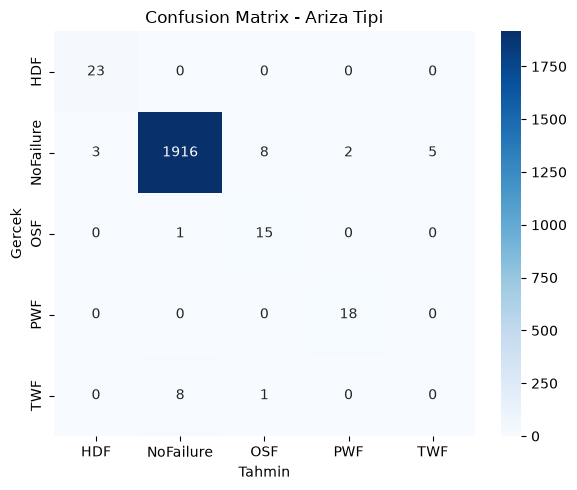

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues', ax=ax)
ax.set_xlabel('Tahmin')
ax.set_ylabel('Gercek')
ax.set_title('Confusion Matrix - Ariza Tipi')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100)
plt.show()

## 3.6 İkili Risk Skoru ve PR-AUC
Modelin "None" olasılığından risk skorunu türetiyoruz: risk = 1 − P(None). Gerçek etiket olarak `Machine failure` sütununu kullanıyoruz (RNF kaynaklı, öngörülemeyen 18 arıza da dahil — modelin gerçek iş hedefine göre ne kadar başarılı olduğunu görmek için).

PR-AUC: 0.8942


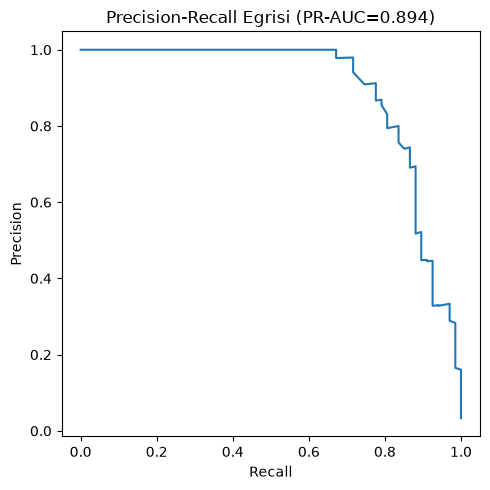

In [7]:
proba = clf.predict_proba(X_test)
none_idx = list(clf.classes_).index('NoFailure')
risk_score = 1 - proba[:, none_idx]

precision, recall, thresholds = precision_recall_curve(mf_test, risk_score)
pr_auc = average_precision_score(mf_test, risk_score)
print('PR-AUC:', round(pr_auc, 4))

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Egrisi (PR-AUC={pr_auc:.3f})')
plt.tight_layout()
plt.savefig('../models/pr_curve.png', dpi=100)
plt.show()

## 3.7 İş kuralı eşiği (0.60) ile risk uyarısı
PDF'teki öneri: olasılık 0.60 üzerindeyse kayıt bir "risk uyarısı" olarak listeye düşer.

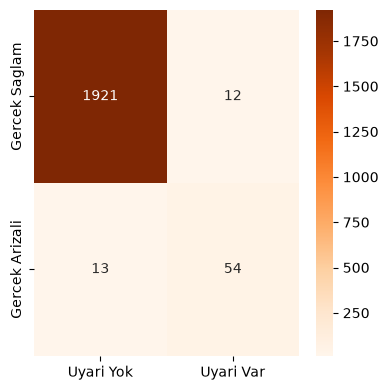

Esik=0.60 -> Precision: 0.818
Esik=0.60 -> Recall: 0.806


In [8]:
THRESHOLD = 0.60
risk_flag = (risk_score >= THRESHOLD).astype(int)
cm_binary = confusion_matrix(mf_test, risk_flag)
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(cm_binary, annot=True, fmt='d', xticklabels=['Uyari Yok','Uyari Var'], yticklabels=['Gercek Saglam','Gercek Arizali'], cmap='Oranges', ax=ax)
plt.tight_layout()
plt.savefig('../models/threshold_confusion_matrix.png', dpi=100)
plt.show()

from sklearn.metrics import precision_score, recall_score
print('Esik=0.60 -> Precision:', round(precision_score(mf_test, risk_flag), 3))
print('Esik=0.60 -> Recall:', round(recall_score(mf_test, risk_flag), 3))

## 3.8 Özellik Önem Sıralaması (Feature Importance)

Tool wear [min]            0.235004
power_w                    0.224180
Torque [Nm]                0.176884
temp_diff                  0.158764
Rotational speed [rpm]     0.122272
Air temperature [K]        0.043342
Process temperature [K]    0.020687
Type_L                     0.010995
Type_M                     0.004030
Type_H                     0.003842
dtype: float64


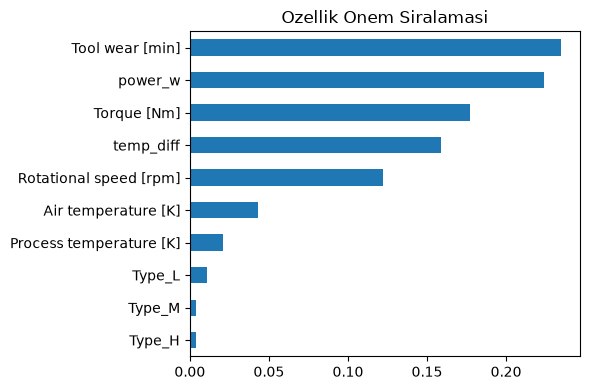

In [9]:
importances = pd.Series(clf.feature_importances_, index=feature_columns).sort_values(ascending=False)
print(importances)
fig, ax = plt.subplots(figsize=(6,4))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Ozellik Onem Siralamasi')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=100)
plt.show()

## 3.9 Modeli Kaydetme (joblib)

In [10]:
artifact = {
    'model': clf,
    'feature_columns': feature_columns,
    'label_classes': clf.classes_.tolist(),
    'threshold': THRESHOLD,
}
joblib.dump(artifact, '../models/model.pkl')
print('Kaydedildi: ../models/model.pkl')

Kaydedildi: ../models/model.pkl
